In [1]:
import sys
sys.path.append('../simulation')
from chi_computation import compute_chi
from filter_functions import F_Hahn, F_CPMG
from noise_models import total_noise, pink_noise, white_noise, lorentzian_noise
from inversion import alvarez_suter, tikhonov, bayesian_spectroscopy

import numpy as np
import matplotlib.pyplot as plt


In [2]:
omega = np.linspace(0, 10e6, 10000)
A_pink = 1e9
alpha = 1.0
A_white = 1e3
A_lorentzian = 5e5
f0 = 5e6
gamma = 5e4

c:\Users\omaru\Projects\qubit-noise-spectroscopy\notebooks\../simulation\noise_models.py:4: RuntimeWarning: divide by zero encountered in divide
  return np.where(f == 0, 0, A / f**alpha)


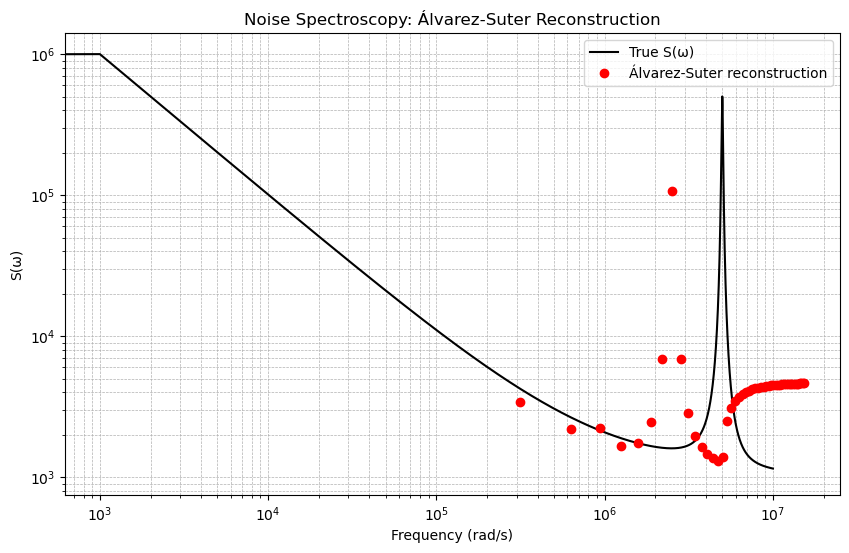

In [3]:
n_list = np.arange(1, 50)
t_fixed = 10e-6

omega_probe, S_reconstructed = alvarez_suter(t_fixed, n_list, omega,
    total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma))

plt.figure(figsize=(10, 6))
plt.plot(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), 
         label='True S(ω)', color='black')
plt.plot(omega_probe, S_reconstructed, 'o', label='Álvarez-Suter reconstruction', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('S(ω)')
plt.title('Noise Spectroscopy: Álvarez-Suter Reconstruction')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

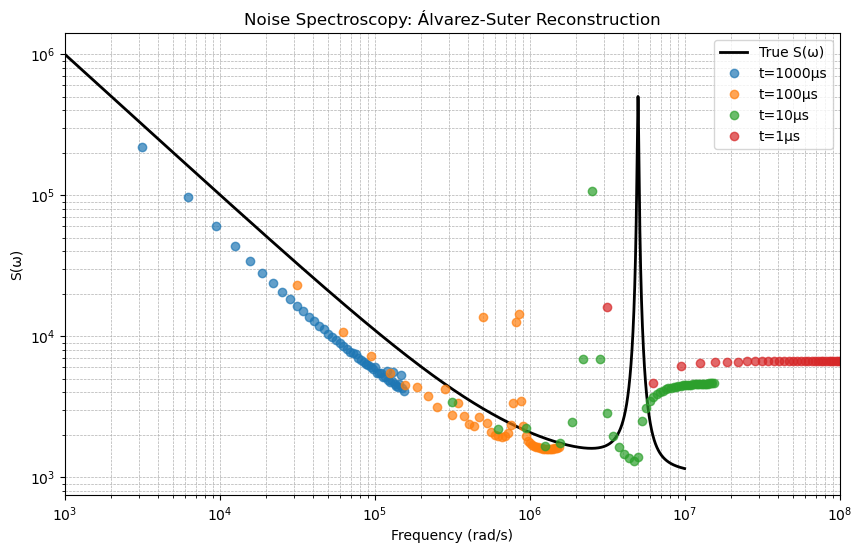

In [4]:
t_values = [1000e-6, 100e-6, 10e-6, 1e-6]
n_list = np.arange(1, 50)

plt.figure(figsize=(10, 6))
plt.plot(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), 
         label='True S(ω)', color='black', linewidth=2)

for t_fixed in t_values:
    omega_probe, S_reconstructed = alvarez_suter(t_fixed, n_list, omega,
        total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma))
    plt.plot(omega_probe, S_reconstructed, 'o', label=f't={t_fixed*1e6:.0f}µs', alpha=0.7)

plt.xlim(1e3, 1e8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('S(ω)')
plt.title('Noise Spectroscopy: Álvarez-Suter Reconstruction')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

c:\Users\omaru\Projects\qubit-noise-spectroscopy\notebooks\../simulation\filter_functions.py:7: RuntimeWarning: invalid value encountered in divide
  return np.where(omega == 0, 0 , (16 * (np.sin(omega * t / 4) ** 4) / omega ** 2))


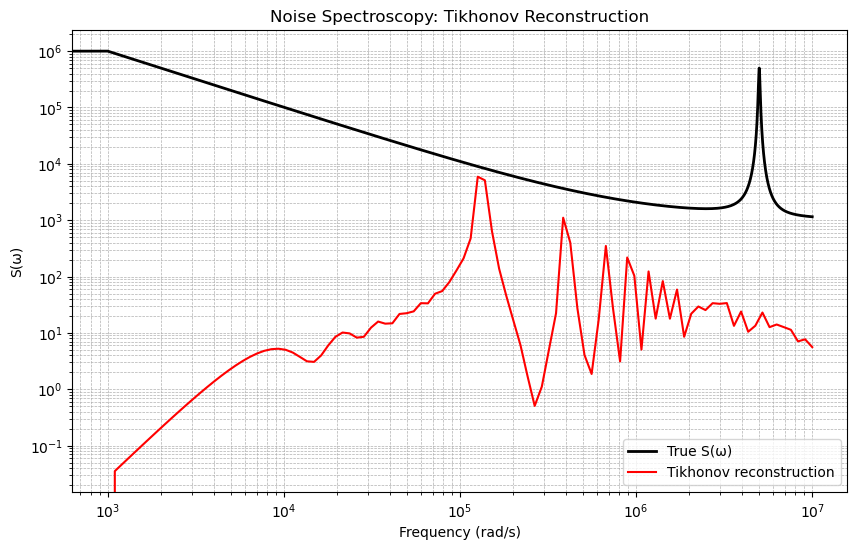

In [5]:
t_list = np.linspace(1e-6, 500e-6, 100)
omega_recon = np.logspace(3, 7, 100)
chi_list = []
for t in t_list:
    F_vals = F_Hahn(omega, t)
    chi = compute_chi(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), F_vals)
    chi_list.append(chi)

omega_recon, S_tik = tikhonov(t_list, chi_list, omega_recon, lambda_reg=1e-5)

plt.figure(figsize=(10, 6))
plt.plot(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), 
         label='True S(ω)', color='black', linewidth=2)
plt.plot(omega_recon, S_tik, label='Tikhonov reconstruction', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('S(ω)')
plt.title('Noise Spectroscopy: Tikhonov Reconstruction')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [6]:
def bayesian_spectroscopy(omega, S_true, n_experiments=50, sigma_rel=0.1,
                          A_bounds=(4,9), alpha_bounds=(0.5,1.5), S0_bounds=(0,4)):
    A_grid     = np.logspace(*A_bounds,     20)
    alpha_grid = np.linspace(*alpha_bounds, 20)
    S0_grid    = np.logspace(*S0_bounds,    20)

    # Precompute all S models — shape (20, 20, 20, len(omega))
    A  = A_grid[:, None, None, None]
    al = alpha_grid[None, :, None, None]
    S0 = S0_grid[None, None, :, None]
    om = omega[None, None, None, :]

    S_models = np.where(om == 0, 0, A / om**al) + S0

    # --- FIX 1: work in log-space from the start ---
    log_post = np.zeros((20, 20, 20))          # uniform log-prior

    t_candidates = np.logspace(-6, -3, 20)
    n_candidates = np.arange(1, 20)

    for exp in range(n_experiments):
        t = t_candidates[exp % len(t_candidates)]
        n = int(n_candidates[exp % len(n_candidates)])

        F_vals   = F_CPMG(omega, t, n)
        chi_meas = compute_chi(omega, S_true, F_vals)

        # --- FIX 2: / np.pi, not / (2*np.pi) ---
        integrand = S_models * F_vals[None, None, None, :]
        chi_pred  = np.trapz(integrand, omega, axis=-1) / np.pi

        # --- FIX 3: adaptive sigma scales with the measurement ---
        sigma = max(sigma_rel * abs(chi_meas), 1e-6)

        log_like  = -(chi_meas - chi_pred)**2 / (2 * sigma**2)

        # Additive update in log-space, re-centre to prevent overflow
        log_post += log_like
        log_post -= log_post.max()             # shift so max=0 before each step

    idx = np.unravel_index(log_post.argmax(), log_post.shape)
    posterior = np.exp(log_post)
    posterior /= posterior.sum()

    return A_grid[idx[0]], alpha_grid[idx[1]], S0_grid[idx[2]], posterior

In [7]:
S_true = total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma)

A_est, alpha_est, S0_est, posterior = bayesian_spectroscopy(
    omega, S_true, n_experiments=100
)

print(f"True:      A={A_pink:.2e}, alpha={alpha:.2f}, S0={A_white:.2e}")
print(f"Estimated: A={A_est:.2e}, alpha={alpha_est:.2f}, S0={S0_est:.2e}")

C:\Users\omaru\AppData\Local\Temp\ipykernel_28692\3245169497.py:13: RuntimeWarning: divide by zero encountered in divide
  S_models = np.where(om == 0, 0, A / om**al) + S0
C:\Users\omaru\AppData\Local\Temp\ipykernel_28692\3245169497.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  chi_pred  = np.trapz(integrand, omega, axis=-1) / np.pi


True:      A=1.00e+09, alpha=1.00, S0=1.00e+03
Estimated: A=1.00e+09, alpha=1.08, S0=8.86e+02


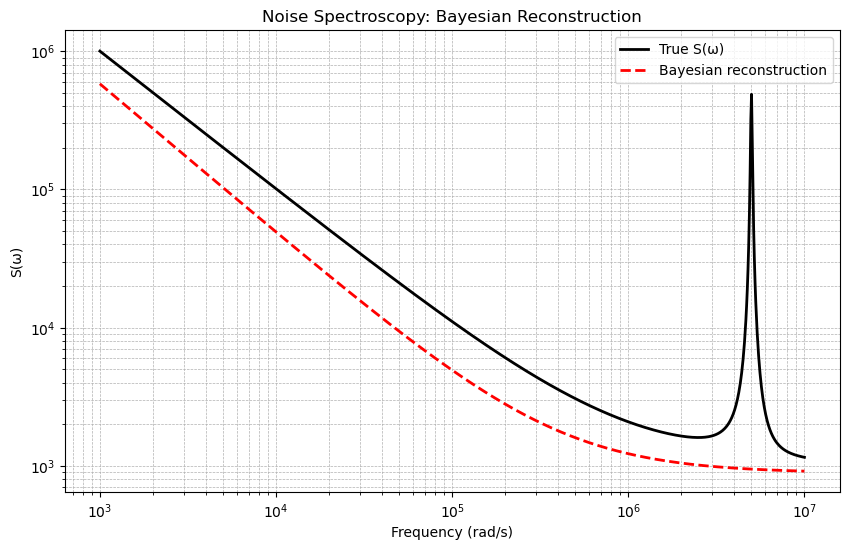

In [8]:
omega_plot = np.logspace(3, 7, 1000)
S_true_plot = total_noise(omega_plot, A_pink, alpha, A_white, A_lorentzian, f0, gamma)
S_bayes_plot = np.where(omega_plot == 0, 0, A_est / omega_plot**alpha_est) + S0_est

plt.figure(figsize=(10, 6))
plt.plot(omega_plot, S_true_plot, 'k-', linewidth=2, label='True S(ω)')
plt.plot(omega_plot, S_bayes_plot, 'r--', linewidth=2, label='Bayesian reconstruction')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('S(ω)')
plt.title('Noise Spectroscopy: Bayesian Reconstruction')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()